In [1]:
import statistics
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Central Tendency


#### Mean


In [2]:
marks = [45, 50, 60, 70, 80, 90, 100]
mean_mark = sum(marks) / len(marks)

f'Mean : {mean_mark:.2f}'

'Mean : 70.71'

#### Median


In [3]:
marks = [45, 50, 60, 70, 80, 90, 100]
median_marks = statistics.median(marks)

f'Median : {median_marks}'

'Median : 70'

In [4]:
df = pd.DataFrame({
    'Marks' : [45, 50, 55, 60, 90, 90]
})

print(f'Mean : {df["Marks"].mean():.2f}\n')
print(f'Median : {df["Marks"].median():.2f}\n')
print(f'Mode : {df["Marks"].mode()}\n')
print(f'Variance : {np.var(df["Marks"]):.2f}')

Mean : 65.00

Median : 57.50

Mode : 0    90
Name: Marks, dtype: int64

Variance : 333.33


## IQR


In [5]:
data = [5, 10, 15, 20, 25, 30, 35, 40 ,200]

Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
print(f'Q1 = {Q1} | Q3 = {Q3}')

Q1 = 15.0 | Q3 = 35.0


In [6]:
IQR  = Q3 - Q1
print("IQR : ",IQR)

IQR :  20.0


In [7]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(f'Lower : {lower} | Upper : {upper}')

Lower : -15.0 | Upper : 65.0


In [8]:
outliers = [x for x in data if x < lower or x > upper]
print(outliers)

[200]


## Probability


In [9]:
sample_space = {1, 2, 3, 4, 5, 6}
event_A = {2, 4, 6}

print(f'Sample Space : {sample_space}')
print(f'Event A : {event_A}')

Sample Space : {1, 2, 3, 4, 5, 6}
Event A : {2, 4, 6}


In [10]:
P_A = len(event_A) / len(sample_space)
P_A

0.5

## Conditional Probability


In [11]:
event_B = {4, 5, 6}
intersection = event_A.intersection(event_B)

P_A_given_B = len(intersection) / len(event_B)

print('Event B:', event_B)
print('A n B :', intersection)
print('P(A|B):', P_A_given_B)

Event B: {4, 5, 6}
A n B : {4, 6}
P(A|B): 0.6666666666666666


In [12]:
pds = 0.01
ppd = 0.99
pp = 0.05
pdp = (ppd *pds)/pp
print("P Disease Given Positive:",pdp)

P Disease Given Positive: 0.198


In [13]:

P_Disease_given_Positive = (
    ppd * pds
) / pp

print('Bayes Theorem Example')
print('P(Disease) = ', pds)
print('P(Positive | Disease) =', ppd)
print('P(Positive) = ',pp)


Bayes Theorem Example
P(Disease) =  0.01
P(Positive | Disease) = 0.99
P(Positive) =  0.05


In [14]:
df = pd.DataFrame({
    'Hours': [1, 2, 3, 4, 5],
    'Marks': [20, 30, 40, 50, 60]  
})

corr = df['Hours'].corr(df['Marks']) 
print('Pearson Correlation:', corr)


Pearson Correlation: 1.0


## Spearman Correlation


In [15]:
df = pd.DataFrame({
    'Rank_Study': [1, 2, 3, 4, 5],
    'Rank_Marks': [2, 1, 3, 5, 4]
})
corr = df.corr(method='spearman')

print('Spearman Correlation :')
print(corr)


Spearman Correlation :
            Rank_Study  Rank_Marks
Rank_Study         1.0         0.8
Rank_Marks         0.8         1.0


In [16]:
df = pd.DataFrame({
    'Hours': [1,2,3,4,5],
    'Marks': [20,40,50,70,90],
    'Sleep':[8,7,6,5,4]
})

df.corr()

,Hours,Marks,Sleep
Hours,1.00000,0.99485,-1.00000
Marks,0.99485,1.00000,-0.99485
Sleep,-1.00000,-0.99485,1.00000


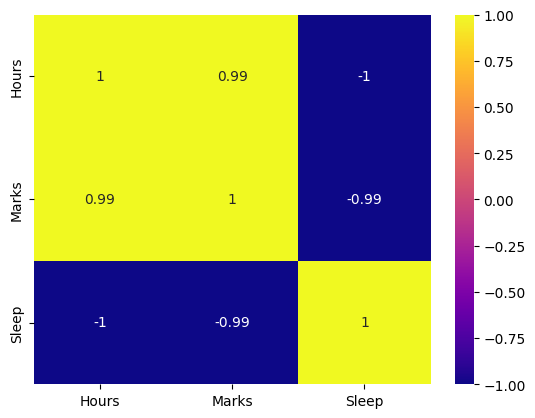

In [17]:
sns.heatmap(df.corr(), annot=True,cmap='plasma')
plt.show()

## Normal Distribution


In [18]:
data = np.random.normal(
    loc = 70, scale = 10, size=1000
)

mean = np.mean(data)
std = np.std(data)

print(f'Mean : {round(mean,2)}')
print(f'Standard Deviation : {round(std,2)}')

Mean : 70.23
Standard Deviation : 10.12


## Histogram


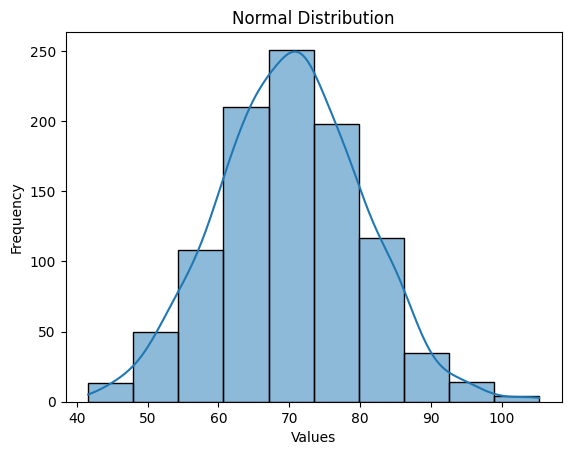

In [25]:
plt.figure()
sns.histplot(data,bins=10, kde=True)

plt.title('Normal Distribution')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()

In [26]:
df = sns.load_dataset('diamonds')
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


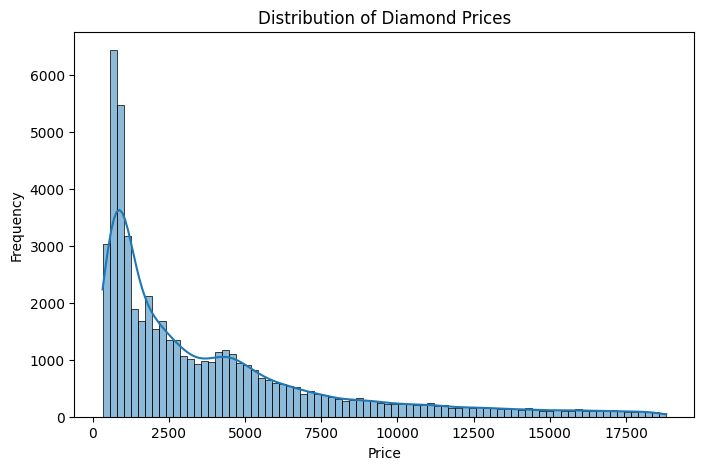

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(df['price'], kde=True)

plt.title('Distribution of Diamond Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.show()

In [29]:
left_skew = df['price'].max() - df['price']

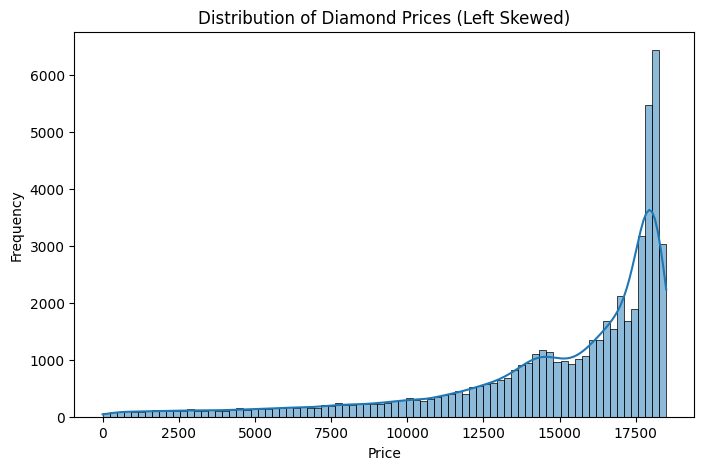

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(left_skew, kde=True)

plt.title('Distribution of Diamond Prices (Left Skewed)')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.show()

## Z Score


In [31]:
scores = [60, 65, 70, 75, 80]

mean = np.mean(scores)
std = np.std(scores)

scores = 80

z_score = (scores - mean) / std

print(f'Mean : {mean}')
print(f'Standard Deviation : {std}')
print(f'Z-Score : {z_score}')

Mean : 70.0
Standard Deviation : 7.0710678118654755
Z-Score : 1.414213562373095
